In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
df = pd.read_csv("StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [4]:
df['math score'].fillna(df['math score'].mean(), inplace=True)

In [5]:
df['gender'].fillna(df['gender'].mode()[0], inplace=True)

In [6]:
df['gender'].unique()
df['race/ethnicity'].unique()

array(['group B', 'group C', 'group A', 'group D', 'group E'],
      dtype=object)

In [7]:
df['gender'] = df['gender'].str.lower()
df['gender'].replace({'f':'female', 'm':'male'}, inplace=True)

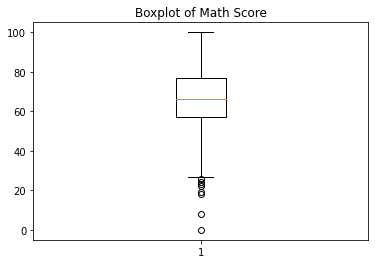

In [8]:
plt.boxplot(df['math score'])
plt.title("Boxplot of Math Score")
plt.show()

In [9]:
Q1 = df['math score'].quantile(0.25)
Q3 = df['math score'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['math score'] < lower_bound) | 
              (df['math score'] > upper_bound)]

print("Number of Outliers:", outliers.shape[0])

Number of Outliers: 8


In [10]:
df = df[(df['math score'] >= lower_bound) & 
        (df['math score'] <= upper_bound)]

In [11]:
Q1 = df['math score'].quantile(0.25)
Q3 = df['math score'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['math score'] < lower_bound) | 
              (df['math score'] > upper_bound)]

print("Number of Outliers:", outliers.shape[0])

Number of Outliers: 0


In [12]:
df['math score'].skew()

-0.06930576171107476

In [13]:
df['math_score_log'] = np.log1p(df['math score'])

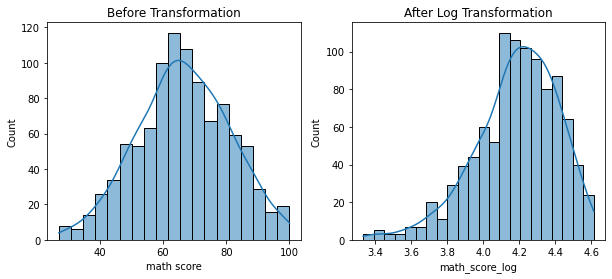

In [14]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(df['math score'], kde=True)
plt.title("Before Transformation")

plt.subplot(1,2,2)
sns.histplot(df['math_score_log'], kde=True)
plt.title("After Log Transformation")

plt.show()

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df['math_score_scaled'] = scaler.fit_transform(df[['math score']])

In [16]:
df.to_csv("cleaned_academic_performance.csv", index=False)

In [17]:
df.head()


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,math_score_log,math_score_scaled
0,female,group B,bachelor's degree,standard,none,72,72,74,4.290459,0.379254
1,female,group C,some college,standard,completed,69,90,88,4.248495,0.173106
2,female,group B,master's degree,standard,none,90,95,93,4.510860,1.616141
3,male,group A,associate's degree,free/reduced,none,47,57,44,3.871201,-1.338645
4,male,group C,some college,standard,none,76,78,75,4.343805,0.654118


In [18]:
df.describe()

,math score,reading score,writing score,math_score_log,math_score_scaled
count,992.000000,992.000000,992.000000,992.000000,9.920000e+02
mean,66.480847,69.461694,68.373992,4.186620,-1.982061e-16
std,14.559999,14.269305,14.812186,0.230803,1.000504e+00
min,27.000000,23.000000,15.000000,3.332205,-2.712965e+00
25%,57.000000,60.000000,58.000000,4.060443,-6.514855e-01
50%,66.000000,70.000000,69.000000,4.204693,-3.304185e-02
75%,77.000000,80.000000,79.000000,4.356709,7.228338e-01
max,100.000000,100.000000,100.000000,4.615121,2.303301e+00
